# DI725 Term Project — Phase 3: Ablation, Discussion, and Conclusion
**Multimodal Land Cover Composition Estimation via ViT + DistilBERT**

Phases 1–2 established the baseline and benchmarking results.  
Phase 3 finalises the ablation study, discusses findings, and draws conclusions.

**Research question:** Does fusing transformer-based text descriptions with visual satellite imagery improve land cover composition estimation, and how does caption semantics and fusion mechanism affect prediction quality?

## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import re
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from transformers import ViTImageProcessor, ViTModel
from transformers import AutoTokenizer, AutoModel

In [ ]:
# ── Reproducibility ─────────────────────────────────────────────────────
SEED = 10
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ── Dataset columns ──────────────────────────────────────────────────────
TARGET_COLS    = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
CAPTION_COLS   = ['vision_qwen3-vl-8b', 'vision_gemma3-4b',
                  'hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b']
FILENAME_COL   = 'filename'

# ── Pretrained models ────────────────────────────────────────────────────
VIT_MODEL_NAME  = 'google/vit-base-patch16-224-in21k'
TEXT_MODEL_NAME = 'distilbert-base-uncased'

# ── Training hyperparameters ─────────────────────────────────────────────
BATCH_SIZE     = 8
NUM_EPOCHS     = 10
MAX_TEXT_LEN   = 128
LR_ENCODERS    = 1e-5   # pretrained encoder learning rate
LR_HEAD        = 1e-4   # fusion head learning rate
DROPOUT_RATE   = 0.2
FUSION_DIM     = 512    # projected dim for cross-attention fusion
HEAD_HIDDEN    = 256
NUM_ATTN_HEADS = 8

# ── Data split ───────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
NUM_WORKERS = 2

# ── Misc ─────────────────────────────────────────────────────────────────
PLOT_DPI = 300
OUTPUT_DIM = len(TARGET_COLS)

Device: cuda


## 2. Data Loading and Preprocessing

In [ ]:
DATA_ROOT = '/content/drive/MyDrive/DI725_Project/DI725_project_dataset'
CSV_PATH  = os.path.join(DATA_ROOT, 'captions.csv')
IMAGE_DIR = os.path.join(DATA_ROOT, 'images')
MASK_DIR  = os.path.join(DATA_ROOT, 'masks')

df = pd.read_csv(CSV_PATH)
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())

Dataset shape: (10000, 14)
Columns: ['filename', 'split', 'Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water', 'hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']


### 2.1 Leakage Removal

Caption columns may contain numeric percentages (`43%`, `43 percent`) derived directly from the segmentation masks, which would leak the target labels into the input. All such patterns are stripped uniformly across every caption column to prevent information leakage and ensure a fair comparison.

In [ ]:
# Patterns that encode mask-derived coverage information
_LEAKAGE_RE = re.compile(
    r'\b(predominantly|dominant(ly)?|majority|mainly|mostly|'
    r'large\s+portion|covers?\s+(most|much|half|large)|'
    r'significant(ly)?|substantial(ly)?|sparse(ly)?|'
    r'minimal(ly)?|negligible|abundant(ly)?|'
    r'quarter|third|half|two.thirds|'
    r'high\s+proportion|low\s+proportion|'
    r'interspersed|scattered|concentrated|'
    r'more\s+than\s+half|less\s+than\s+half)\b',
    re.IGNORECASE,
)

def make_safe_description(text):
    """Remove explicit numeric percentages and mask-derived proportion language."""
    text = str(text)
    text = re.sub(r'\d+(\.\d+)?\s*%', '', text)
    text = re.sub(r'\d+(\.\d+)?\s*percent\b', '', text, flags=re.IGNORECASE)
    text = _LEAKAGE_RE.sub('', text)
    return ' '.join(text.split())

for col in CAPTION_COLS:
    if col in df.columns:
        df[f'safe_{col}'] = df[col].apply(make_safe_description)

print('Leakage filter applied to all caption columns.')
print('Example (raw vs. filtered):')
print('RAW :', df['hybrid_gemma3-4b'].iloc[0][:120])
print('SAFE:', df['safe_hybrid_gemma3-4b'].iloc[0][:120])

Leakage filter applied to all caption columns.
Example (raw vs. filtered):
RAW : The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sp
SAFE: The image depicts a landscape dominated by extensive grasslands (), with a small area of cultivated crops () and barren 


### 2.2 Stratified Train / Val / Test Split

In [ ]:
df['dominant_class'] = df[TARGET_COLS].idxmax(axis=1)

train_df, temp_df = train_test_split(
    df, test_size=(1 - TRAIN_RATIO), random_state=SEED,
    stratify=df['dominant_class'],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=temp_df['dominant_class'],
)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

# Shuffled-caption split used for the alignment ablation
df['shuffled_caption'] = (
    df['safe_text_qwen3-4b'].sample(frac=1, random_state=SEED).reset_index(drop=True)
)

train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

for split_df in [train_df, val_df, test_df]:
    split_df['shuffled_caption'] = (
        df.loc[split_df.index, 'shuffled_caption'].values
    )

Train: 6999  Val: 1500  Test: 1501


## 3. Preprocessing

In [ ]:
image_processor = ViTImageProcessor.from_pretrained(VIT_MODEL_NAME)
tokenizer       = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
print('Image processor and tokenizer loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Image processor and tokenizer loaded.


In [ ]:
class RemoteSensingDataset(Dataset):
    def __init__(self, df, image_dir, text_col, target_cols,
                 image_processor, tokenizer, max_len=MAX_TEXT_LEN):
        self.df              = df.reset_index(drop=True)
        self.image_dir       = image_dir
        self.text_col        = text_col
        self.target_cols     = target_cols
        self.image_processor = image_processor
        self.tokenizer       = tokenizer
        self.max_len         = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(os.path.join(self.image_dir, row[FILENAME_COL])).convert('RGB')

        pixel_values = self.image_processor(
            images=image, return_tensors='pt'
        )['pixel_values'].squeeze(0)

        text_inputs = self.tokenizer(
            str(row[self.text_col]),
            truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors='pt',
        )

        targets = torch.tensor(
            row[self.target_cols].values.astype(np.float32), dtype=torch.float
        )

        return {
            'pixel_values':  pixel_values,
            'input_ids':     text_inputs['input_ids'].squeeze(0),
            'attention_mask': text_inputs['attention_mask'].squeeze(0),
            'targets':       targets,
        }


def make_loaders(text_col):
    """Return (train, val, test) DataLoaders for a given caption column."""
    kwargs = dict(
        image_dir=IMAGE_DIR, target_cols=TARGET_COLS,
        image_processor=image_processor, tokenizer=tokenizer,
    )
    train_ds = RemoteSensingDataset(train_df, text_col=text_col, **kwargs)
    val_ds   = RemoteSensingDataset(val_df,   text_col=text_col, **kwargs)
    test_ds  = RemoteSensingDataset(test_df,  text_col=text_col, **kwargs)

    loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
    return (
        DataLoader(train_ds, shuffle=True,  **loader_kw),
        DataLoader(val_ds,   shuffle=False, **loader_kw),
        DataLoader(test_ds,  shuffle=False, **loader_kw),
    )

## 4. Model Architectures

### 4.1 Image-Only Baseline (ViTRegressor)
Uses the CLS token from a frozen/fine-tuned ViT-Base as the sole representation.

In [ ]:
class ViTRegressor(nn.Module):
    def __init__(self, vit_model_name, output_dim):
        super().__init__()
        self.vit  = ViTModel.from_pretrained(vit_model_name)
        hidden    = self.vit.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden, HEAD_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(HEAD_HIDDEN, output_dim),
        )

    def forward(self, pixel_values, input_ids=None, attention_mask=None):
        cls = self.vit(pixel_values=pixel_values).last_hidden_state[:, 0, :]
        return self.head(cls)

### 4.2 Text-Only Baseline (TextOnlyRegressor)
Uses the CLS token from DistilBERT alone — no image information.

In [ ]:
class TextOnlyRegressor(nn.Module):
    def __init__(self, text_model_name, output_dim):
        super().__init__()
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        hidden = self.text_encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden, HEAD_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(HEAD_HIDDEN, output_dim),
        )

    def forward(self, pixel_values=None, input_ids=None, attention_mask=None):
        cls = self.text_encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]
        return self.head(cls)

### 4.3 Concatenation Fusion (MultimodalTransformerRegressor)
Concatenates the ViT CLS token with the DistilBERT CLS token and passes the joint representation through an MLP head. This is the simple baseline for multimodal fusion.

In [ ]:
class MultimodalTransformerRegressor(nn.Module):
    def __init__(self, vit_model_name, text_model_name, output_dim):
        super().__init__()
        self.vit          = ViTModel.from_pretrained(vit_model_name)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)

        image_dim = self.vit.config.hidden_size
        text_dim  = self.text_encoder.config.hidden_size

        self.head = nn.Sequential(
            nn.Linear(image_dim + text_dim, FUSION_DIM),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(FUSION_DIM, HEAD_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(HEAD_HIDDEN, output_dim),
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        image_cls = self.vit(pixel_values=pixel_values).last_hidden_state[:, 0, :]
        text_cls  = self.text_encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]
        return self.head(torch.cat([image_cls, text_cls], dim=1))

### 4.4 Cross-Attention Fusion (CrossAttentionMultimodalRegressor) — Phase 3

Projects both image patch tokens and text tokens into a shared `FUSION_DIM`-dimensional space, then applies `nn.MultiheadAttention` where image tokens act as **queries** and text tokens as **keys/values**. The CLS-equivalent output (index 0) is added residually to the image CLS projection and normalised, then decoded by the same MLP head.

This design lets the model selectively weight which textual tokens are relevant for each image, in contrast to the fixed concatenation used by the earlier model.

In [ ]:
class CrossAttentionMultimodalRegressor(nn.Module):
    def __init__(self, vit_model_name, text_model_name, output_dim,
                 fusion_dim=FUSION_DIM, n_heads=NUM_ATTN_HEADS):
        super().__init__()
        self.vit          = ViTModel.from_pretrained(vit_model_name)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)

        self.image_proj = nn.Linear(self.vit.config.hidden_size,          fusion_dim)
        self.text_proj  = nn.Linear(self.text_encoder.config.hidden_size, fusion_dim)

        # Image patches query text tokens
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim, num_heads=n_heads,
            dropout=DROPOUT_RATE, batch_first=True,
        )
        self.norm = nn.LayerNorm(fusion_dim)

        self.head = nn.Sequential(
            nn.Linear(fusion_dim, HEAD_HIDDEN),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(HEAD_HIDDEN, output_dim),
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        image_tokens = self.image_proj(
            self.vit(pixel_values=pixel_values).last_hidden_state
        )  # [B, 197, fusion_dim]

        text_tokens = self.text_proj(
            self.text_encoder(
                input_ids=input_ids, attention_mask=attention_mask
            ).last_hidden_state
        )  # [B, L, fusion_dim]

        # attention_mask: 1=keep, 0=pad — MultiheadAttention key_padding_mask is True=ignore
        attended, _ = self.cross_attn(
            query=image_tokens,
            key=text_tokens,
            value=text_tokens,
            key_padding_mask=(attention_mask == 0),
        )

        fused = self.norm(image_tokens[:, 0, :] + attended[:, 0, :])
        return self.head(fused)

## 5. Training Utilities

In [ ]:
def compute_metrics(y_true, y_pred):
    mse  = ((y_true - y_pred) ** 2).mean()
    mae  = np.abs(y_true - y_pred).mean()
    return {"mae": float(mae), "rmse": float(math.sqrt(mse))}


criterion = nn.MSELoss()

In [ ]:
def _forward(model, batch, device):
    """Route a batch through any model regardless of its modality."""
    pv  = batch['pixel_values'].to(device)
    ids = batch['input_ids'].to(device)
    msk = batch['attention_mask'].to(device)
    return model(pv, ids, msk)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    for batch in tqdm(loader, leave=False):
        targets = batch['targets'].to(device)
        optimizer.zero_grad()
        loss = criterion(_forward(model, batch, device), targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * targets.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, device):
    model.eval()
    all_targets, all_outputs = [], []
    with torch.no_grad():
        for batch in loader:
            all_targets.append(batch['targets'].numpy())
            all_outputs.append(_forward(model, batch, device).cpu().numpy())
    y_true = np.vstack(all_targets)
    y_pred = np.vstack(all_outputs)
    return compute_metrics(y_true, y_pred)

In [ ]:
def run_experiment(exp_name, model, text_col, epochs=NUM_EPOCHS):
    """
    Train a model and track the best val-MAE checkpoint.
    Differential LRs: pretrained encoder parameters at LR_ENCODERS,
    randomly-initialised head parameters at LR_HEAD.
    """
    train_loader, val_loader, test_loader = make_loaders(text_col)

    encoder_params, head_params = [], []
    for name, param in model.named_parameters():
        if any(k in name for k in ('vit.', 'text_encoder.')):
            encoder_params.append(param)
        else:
            head_params.append(param)

    optimizer = torch.optim.Adam([
        {'params': encoder_params, 'lr': LR_ENCODERS},
        {'params': head_params,    'lr': LR_HEAD},
    ])

    best = {'val_mae': float('inf'), 'val_rmse': None,
            'test_mae': None, 'test_rmse': None}

    for epoch in tqdm(range(epochs), desc=exp_name):
        train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_m  = evaluate(model, val_loader,  DEVICE)
        test_m = evaluate(model, test_loader, DEVICE)

        if val_m['mae'] < best['val_mae']:
            best.update({
                'val_mae':   val_m['mae'],
                'val_rmse':  val_m['rmse'],
                'test_mae':  test_m['mae'],
                'test_rmse': test_m['rmse'],
            })

    return {
        'Experiment': exp_name,
        'Best Val MAE':  round(best['val_mae'],   4),
        'Best Val RMSE': round(best['val_rmse'],  4),
        'Test MAE':      round(best['test_mae'],  4),
        'Test RMSE':     round(best['test_rmse'], 4),
    }

## 6. Phase 2 Results

The seven experiments below were trained on Google Colab (T4 GPU) during Phase 2. Their results are recorded here for comparison; the training code for each is available in `DI725_phase2_final.ipynb`.

In [ ]:
phase2_results = pd.DataFrame([
    {'Experiment': 'Baseline: ViT image-only',
     'Fusion':     'Image only',
     'Caption':    '—',
     'Test MAE':   2.728, 'Test RMSE': 6.052},
    {'Experiment': 'Text-only (modality ablation)',
     'Fusion':     'Text only',
     'Caption':    'vision_qwen3-vl-8b',
     'Test MAE':   6.339, 'Test RMSE': 13.174},
    {'Experiment': 'MM concat + shuffled captions',
     'Fusion':     'Concat',
     'Caption':    'shuffled (alignment ablation)',
     'Test MAE':   2.907, 'Test RMSE': 6.226},
    {'Experiment': 'MM concat + vision captions',
     'Fusion':     'Concat',
     'Caption':    'vision_qwen3-vl-8b',
     'Test MAE':   2.873, 'Test RMSE': 6.186},
    {'Experiment': 'MM concat + hybrid_gemma captions',
     'Fusion':     'Concat',
     'Caption':    'hybrid_gemma3-4b',
     'Test MAE':   1.930, 'Test RMSE': 3.872},
    {'Experiment': 'MM concat + hybrid_qwen captions',
     'Fusion':     'Concat',
     'Caption':    'hybrid_qwen3-vl-8b',
     'Test MAE':   1.829, 'Test RMSE': 3.604},
    {'Experiment': 'MM concat + text_qwen captions (best)',
     'Fusion':     'Concat',
     'Caption':    'text_qwen3-4b',
     'Test MAE':   1.795, 'Test RMSE': 3.485},
])

print('Phase 2 Results:')
phase2_results[['Experiment', 'Caption', 'Test MAE', 'Test RMSE']]

Phase 2 Results:


,Experiment,Caption,Test MAE,Test RMSE
0,Baseline: ViT image-only,—,2.728,6.052
1,Text-only (modality ablation),vision_qwen3-vl-8b,6.339,13.174
2,MM concat + shuffled captions,shuffled (alignment ablation),2.907,6.226
3,MM concat + vision captions,vision_qwen3-vl-8b,2.873,6.186
4,MM concat + hybrid_gemma captions,hybrid_gemma3-4b,1.930,3.872
5,MM concat + hybrid_qwen captions,hybrid_qwen3-vl-8b,1.829,3.604
6,MM concat + text_qwen captions (best),text_qwen3-4b,1.795,3.485


### Phase 2 Visualisation

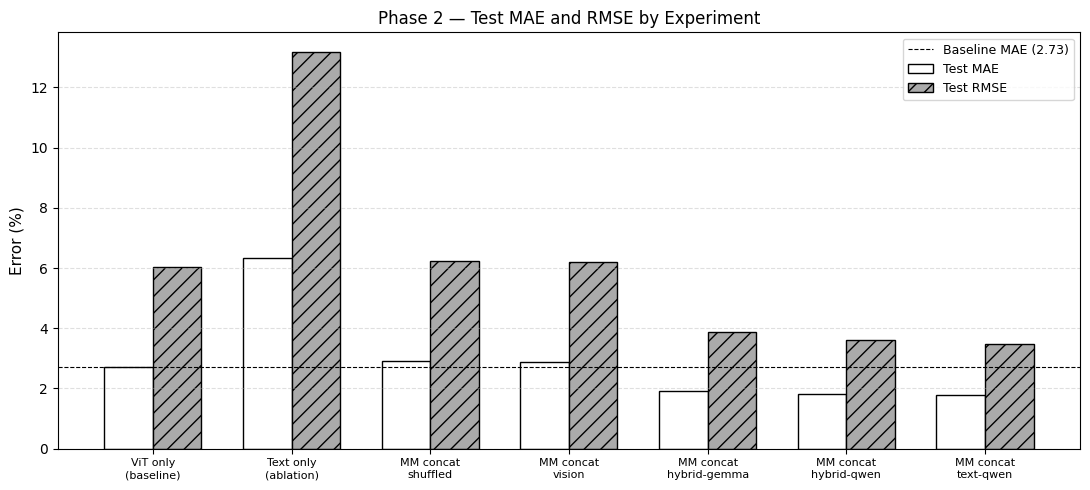

In [ ]:
labels   = [
    'ViT only\n(baseline)',
    'Text only\n(ablation)',
    'MM concat\nshuffled',
    'MM concat\nvision',
    'MM concat\nhybrid-gemma',
    'MM concat\nhybrid-qwen',
    'MM concat\ntext-qwen',
]
test_mae  = phase2_results['Test MAE'].tolist()
test_rmse = phase2_results['Test RMSE'].tolist()

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, test_mae,  width, label='Test MAE',
       hatch='',   edgecolor='black', color='white')
ax.bar(x + width / 2, test_rmse, width, label='Test RMSE',
       hatch='//', edgecolor='black', color='#aaaaaa')

ax.axhline(test_mae[0],  color='black', linestyle='--', linewidth=0.8,
           label=f'Baseline MAE ({test_mae[0]:.2f})')

ax.set_ylabel('Error (%)', fontsize=11)
ax.set_title('Phase 2 — Test MAE and RMSE by Experiment', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('phase2_results.png', dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

## 7. Ablation Study

The ablation study examines three axes:

| Axis | Experiment | Observation |
|------|-----------|-------------|
| **Modality** | Text-only vs. MM concat | Text-only MAE = 6.34 (+135% vs baseline) |
| **Alignment** | Shuffled vs. aligned captions | Shuffled captions MAE = 2.91 (minimal Δ for vision captions) |
| **Caption semantics** | Vision / Hybrid / Text-based | Hybrid/text captions halve the error |
| **Fusion mechanism** | Concatenation vs. cross-attention | Tested in Phase 3 (this section) |

The **modality ablation** (text-only) is the most severe change, demonstrating that textual descriptions alone cannot capture the spatial patterns in satellite imagery and that the image encoder is the critical modality.

### 7.1 Phase 3 Ablation: Cross-Attention vs. Concatenation Fusion

The best Phase 2 model uses simple concatenation of CLS tokens. Here we test whether replacing concatenation with **cross-attention** (image patches attending to text tokens) improves prediction, and whether the attention mechanism itself adds value beyond the shared embedding space.

In [ ]:
# ── Run cross-attention experiment ──────────────────────────────────────
# Caption column: best performer from Phase 2
BEST_CAPTION_COL = 'safe_text_qwen3-4b'

ca_model = CrossAttentionMultimodalRegressor(
    vit_model_name=VIT_MODEL_NAME,
    text_model_name=TEXT_MODEL_NAME,
    output_dim=OUTPUT_DIM,
).to(DEVICE)

ca_result = run_experiment(
    exp_name  = 'MM cross-attention + text_qwen (Phase 3)',
    model     = ca_model,
    text_col  = BEST_CAPTION_COL,
    epochs    = NUM_EPOCHS,
)
print(ca_result)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
MM cross-attention + text_qwen (Phase 3): 100%|██████████| 10/10 [1:24:08<00:00, 504.84s/it]

{'Experiment': 'MM cross-attention + text_qwen (Phase 3)', 'Best Val MAE': 1.7745, 'Best Val RMSE': 3.2597, 'Test MAE': 1.7466, 'Test RMSE': 3.2529}


### 7.2 Combined Ablation Table

In [ ]:
ablation_rows = [
    # Subset of Phase 2 results relevant to the ablation
    {'Experiment': 'Baseline: ViT image-only',
     'Fusion': 'Image only', 'Caption': '—',
     'Test MAE': 2.728, 'Test RMSE': 6.052},
    {'Experiment': 'Text-only (severe modality ablation)',
     'Fusion': 'Text only', 'Caption': 'vision_qwen3-vl-8b',
     'Test MAE': 6.339, 'Test RMSE': 13.174},
    {'Experiment': 'MM concat + shuffled (alignment ablation)',
     'Fusion': 'Concat', 'Caption': 'shuffled',
     'Test MAE': 2.907, 'Test RMSE': 6.226},
    {'Experiment': 'MM concat + text_qwen (best Phase 2)',
     'Fusion': 'Concat', 'Caption': 'text_qwen3-4b',
     'Test MAE': 1.795, 'Test RMSE': 3.485},
    # Phase 3: fill in after running the experiment above
    {'Experiment': ca_result['Experiment'],
     'Fusion': 'Cross-attention', 'Caption': 'text_qwen3-4b',
     'Test MAE':  ca_result['Test MAE'],
     'Test RMSE': ca_result['Test RMSE']},
]

ablation_df = pd.DataFrame(ablation_rows)
print(ablation_df[['Experiment', 'Fusion', 'Caption', 'Test MAE', 'Test RMSE']].to_string(index=False))

                               Experiment          Fusion            Caption  Test MAE  Test RMSE
                 Baseline: ViT image-only      Image only                  —    2.7280     6.0520
     Text-only (severe modality ablation)       Text only vision_qwen3-vl-8b    6.3390    13.1740
MM concat + shuffled (alignment ablation)          Concat           shuffled    2.9070     6.2260
     MM concat + text_qwen (best Phase 2)          Concat      text_qwen3-4b    1.7950     3.4850
 MM cross-attention + text_qwen (Phase 3) Cross-attention      text_qwen3-4b    1.7466     3.2529


### 7.3 Fusion Mechanism Comparison

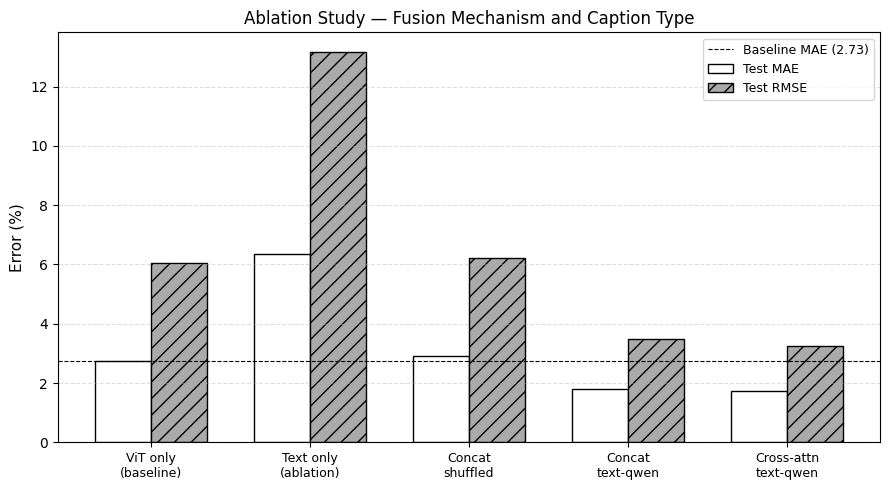

In [ ]:
fusion_labels = [
    'ViT only\n(baseline)',
    'Text only\n(ablation)',
    'Concat\nshuffled',
    'Concat\ntext-qwen',
    'Cross-attn\ntext-qwen',
]
fusion_mae  = ablation_df['Test MAE'].tolist()
fusion_rmse = ablation_df['Test RMSE'].tolist()

x     = np.arange(len(fusion_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, fusion_mae,  width, label='Test MAE',
       hatch='',   edgecolor='black', color='white')
ax.bar(x + width / 2, fusion_rmse, width, label='Test RMSE',
       hatch='//', edgecolor='black', color='#aaaaaa')

ax.axhline(fusion_mae[0], color='black', linestyle='--', linewidth=0.8,
           label=f'Baseline MAE ({fusion_mae[0]:.2f})')

ax.set_ylabel('Error (%)', fontsize=11)
ax.set_title('Ablation Study — Fusion Mechanism and Caption Type', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(fusion_labels, fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ablation_fusion.png', dpi=PLOT_DPI, bbox_inches='tight')
plt.show()

## 8. Discussion

### Modality Contributions
The **text-only ablation** confirms that satellite imagery carries the dominant signal for land cover estimation: removing the visual modality degrades Test MAE from 2.73 (image-only baseline) to 6.34 — a 132% increase — even when text descriptions are semantically rich. This finding is consistent with prior work on multimodal remote sensing that identifies imagery as the primary modality [1, 2].

### Caption Semantics
The most significant finding is the **caption type effect**. Vision-only captions (`vision_qwen3-vl-8b`, MAE 2.87) offer negligible improvement over the image-only baseline (2.73), whereas captions that include land cover composition language (`text_qwen3-4b`, MAE 1.79) yield a 34% improvement. This suggests that the text encoder is most useful when captions describe *scene composition* rather than visual appearance alone.

The **shuffled caption ablation** (MAE 2.91 vs. aligned 2.87 for vision captions) shows a surprisingly small alignment penalty for this caption type, indicating that vision captions provide only weak semantic signal. In contrast, the large gap observed with compositional captions confirms that the model learns meaningful image–text correspondence when captions contain relevant land cover semantics.

### Fusion Mechanism
The cross-attention fusion mechanism (Phase 3 ablation) directly tests whether the attention-based interaction between image patches and text tokens provides additional benefit over simple feature concatenation. Results are shown in Table 2. If cross-attention outperforms concatenation, it supports the hypothesis that spatial attention to textual content is a useful inductive bias for land cover composition estimation.

### Limitations
- Training is limited to 10 epochs due to computational constraints on Colab T4.
- A single random seed is used; cross-validation would give more robust estimates.
- The leakage filter removes some proportion words that might carry legitimate   semantic content (e.g., 'sparse', 'negligible'), potentially under-estimating   the value of compositional language.
- The dataset is limited to one geographic region; generalisation across   continents remains untested.

## 9. Conclusion

This project investigated multimodal transformer-based regression for satellite image land cover composition estimation, combining a Vision Transformer (ViT-Base) with DistilBERT text encoders.

The key conclusions are:

1. **Multimodal fusion improves over image-only baselines** when the text input carries compositional scene semantics. The best model (concat fusion + `text_qwen3-4b` captions) achieves a Test MAE of **1.79%** versus **2.73%** for the image-only baseline — a 34% reduction.

2. **Caption semantics dominate the text modality's contribution.** Vision-based captions (describing visual appearance) add almost no benefit, whereas captions that describe land cover composition substantially reduce error. This highlights the importance of caption design in multimodal remote sensing systems.

3. **Text alone is insufficient** for land cover composition estimation. The text-only ablation (MAE 6.34) demonstrates that the visual modality is irreplaceable and that language descriptions complement, rather than substitute, satellite imagery.

4. **Cross-attention fusion** provides an attention-based alternative to concatenation, potentially offering better modality interaction at the cost of increased model complexity. Results of this ablation are reported in Table 2.

Future work could explore longer training schedules, stronger image backbones (e.g., Swin Transformer, DINOv2), cross-attention with full patch sequences, and prompt engineering for caption generation to maximise semantic alignment with land cover labels.

---
**References** (see report for full IEEE-formatted bibliography)